In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
from astropy.io import fits
%matplotlib inline



In [ ]:
# nside = 2048
# ndevices = 4

nside = 4096
ndevices = 8

map_tau = np.zeros(hp.nside2npix(nside))


for jd in range(ndevices):
    df = pk.load(open(f'/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_tau_sim_B16_nside_{nside}_split_{jd}_{ndevices}.pkl','rb'))
    map_tau += df['map_tau']


    

In [3]:
ra_hp, dec_hp = hp.pix2ang(nside, ipix=np.arange(hp.nside2npix(nside)),lonlat=True)



In [4]:
df = fits.open('/mnt/ceph/users/spandey/websky/halo_input_wM200c_zmax2p5_minM200m_4e13_new.fits')
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']

# indsel = np.where((z_all>0.2) & (z_all<0.5) & (M200m_all>1e14) & (M200m_all<5e15))[0]
indsel = np.where((z_all>0.175) & (z_all<0.225) & (M200c_all>9e13) & (M200c_all<1.1e14))[0]
# indsel = np.where((z_all>0.175) & (z_all<0.225) & (M200c_all>4e14) & (M200c_all<6e14))[0]
print(len(indsel))

ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
M200m_all = M200m_all[indsel]
vlos_all = vlos_all[indsel]




2940


In [5]:
from numpy import (
    where,
    zeros,
    sin,
    cos,
    arccos,
    arcsin,
    arctan2,
    sqrt,
    rad2deg,
    deg2rad,
)

def randsphere(num, ra_range=None, dec_range=None):
    rng = np.random.RandomState()
    ra = rng.uniform(low=ra_range[0], high=ra_range[1], size=num)
    cosdec_min = cos(deg2rad(90.0 + dec_range[0]))
    cosdec_max = cos(deg2rad(90.0 + dec_range[1]))

    v = rng.uniform(low=cosdec_min, high=cosdec_max, size=num)
    v = rng.uniform(low=cosdec_min, high=cosdec_max, size=num)

    np.clip(v, -1.0, 1.0, v)

    # Now this generates on [0,pi)
    dec = np.arccos(v)

    # convert to degrees
    rad2deg(dec, dec)

    # now in range [-90,90.0)
    dec -= 90.0
    return ra, dec


rand_ra, rand_dec = randsphere(20*len(ra_all), ra_range=[0,360], dec_range=[-90,90])



In [6]:
import treecorr
import sys, os
save_dir = './results_test/'
save_filename_jk_obj = 'jk_obj_test.pkl'

# number of patches to divide the full sky on. More of these, better the covariance estimate would be. Just make sure the size of patches is larger than the maximum separation you are interested in.
njk = 256
nthreads = 256
# This is the accuracy setting. If the bin_slop is set to 0.0, it will take longer to run but correlation would be correct. If you want to run it faster, increase the bin_slop to 0.1 or 0.2. This will make the code run faster, but the correlation estimate will be less accurate.
bin_slop = 0.0

# minrad and maxrad are the minimum and maximum separation you are interested in. This is in arcmin. nrad is the number of bins you want to divide the separation range into.
minrad = 2.0
maxrad = 40.0
nrad = 10

# Load the catalogs in treecorr format
if os.path.isfile(save_dir + save_filename_jk_obj):
    datapoint_cat = treecorr.Catalog(ra=ra_all, dec=dec_all, ra_units='degrees',
                                dec_units='degrees', patch_centers=save_dir + save_filename_jk_obj)           

else:
    datapoint_cat = treecorr.Catalog(ra=ra_all, dec=dec_all,  ra_units='degrees',
                                    dec_units='degrees', npatch=njk)
    datapoint_cat.write_patch_centers(save_dir + save_filename_jk_obj)
rand_cat = treecorr.Catalog(ra=rand_ra, dec=rand_dec, ra_units='degrees', dec_units='degrees', patch_centers=save_dir + save_filename_jk_obj)

y1_cat = treecorr.Catalog(ra=ra_hp, dec=dec_hp, k=map_tau, ra_units='degrees', dec_units='degrees')
# y2_cat = treecorr.Catalog(ra=ra_hp, dec=dec_hp, k=tsz2, ra_units='degrees', dec_units='degrees')

# create the correlation objects:
hy1 = treecorr.NKCorrelation(nbins=nrad, min_sep=minrad, max_sep=maxrad, sep_units='arcmin', verbose=0,num_threads=nthreads, bin_slop=bin_slop, var_method='jackknife')
ry1 = treecorr.NKCorrelation(nbins=nrad, min_sep=minrad, max_sep=maxrad, sep_units='arcmin', verbose=0,num_threads=nthreads, bin_slop=bin_slop, var_method='jackknife')

print('doing h x y1 calculation')
hy1.process(datapoint_cat, y1_cat)

print('doing r x y1 calculation')
ry1.process(rand_cat, y1_cat)

hy1.calculateXi(rk=ry1)

xi_hy1 = hy1.xi
r_hy = np.exp(hy1.meanlogr)
cov_hy1 = hy1.cov





doing h x y1 calculation
doing r x y1 calculation


: 

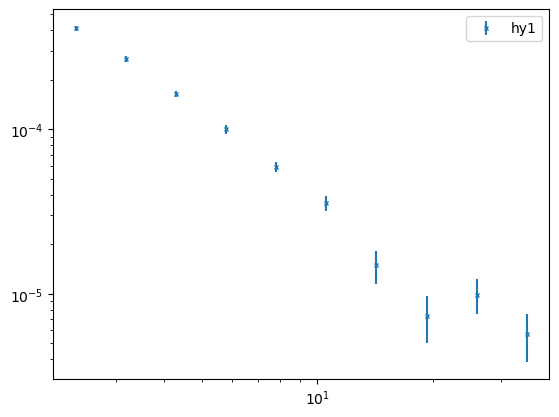

In [7]:
# print(chi2)
import matplotlib.pyplot as plt
plt.figure()
plt.errorbar(r_hy, xi_hy1, yerr=np.sqrt(np.diag(cov_hy1)), ls='', marker='x', ms=3.0, label='hy1')
plt.legend()
plt.xscale('log')
plt.yscale('log')




In [8]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
# from get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants
from tqdm import tqdm
# from time import time
import time
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml

# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
# from halo_processing_utils import process_halo



def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 8.0
halo_params_dict['nr'] = 86
halo_params_dict['zmax'] = 2.75
halo_params_dict['nz'] = 87
halo_params_dict['lg10_Mmin'] = 13.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 78

from get_B12_profile import Battaglia_12_16
import helpers.constants as constants
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}

profiles_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)





/tmp/ipykernel_1652372/3759609679.py:9: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from get_sim_maps import setup_sim_map, get_sim_map

mock_params_dict_setup = {}
mock_params_dict_setup['nside'] = nside
mock_params_dict_setup['get_ymap'] = True
mock_params_dict_setup['get_kSZmap'] = True
mock_params_dict_setup['get_taumap'] = True
mock_params_dict_setup['get_kappamap'] = False
mock_params_dict_setup['get_galmap'] = False
mock_params_dict_setup['smooth_profiles'] = True
B12_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=profiles_test)



In [10]:
# rp_array = profiles_test.r_array[2:-2].astype(jnp.float32)
rp_array = B12_test.rp_array


In [81]:
# from functools import partial
# from jax import grad, jit, vmap
# from base_class import get_vmapped_func, get_vmapped_func_warg
# import jax.scipy.integrate as jsi


# rp_array = profiles_test.r_array[2:-2].astype(jnp.float32)

# @partial(jit, static_argnums=(4, 5))
# def _generic_2D_projection(jrp, jz, jM, mat_physical, const_factor=1.0, num_trapz_points=32):
#     """Generic 2D projection helper"""    
#     rp = rp_array[jrp]
#     zval = profiles_test.z_array[jz]
#     r_max = jnp.minimum(jnp.max(profiles_test.r_array), rp * 100.0)
#     r_array_here = jnp.exp(jnp.linspace(jnp.log(rp*1.01), jnp.log(r_max), num_trapz_points))
    
#     quantity_rarray = jnp.exp(jnp.interp(
#         jnp.log(r_array_here), 
#         jnp.log(profiles_test.r_array/(1 + zval)), 
#         jnp.log(mat_physical[:,jz, jM])
#     ))
    
#     integrand = r_array_here * quantity_rarray / jnp.sqrt(r_array_here**2 - rp**2)
#     return const_factor * 2.0 * jsi.trapezoid(integrand * r_array_here, jnp.log(r_array_here))


# @partial(jit, static_argnums=(3))        
# def get_ne2D_physical_proj(jrp, jz, jM, num_trapz_points=32):
#     """Compute ne2D projection"""
#     return _generic_2D_projection(jrp, jz, jM, profiles_test.ne_mat_physical, 1.0, num_trapz_points)

# ne_2d_proj = get_vmapped_func(get_ne2D_physical_proj, 3)(
#                 jnp.arange(len(rp_array)), 
#                 jnp.arange(len(profiles_test.z_array)), 
#                 jnp.arange(len(profiles_test.M_array))
#             ).T




In [82]:
# ne_2d_proj.shape


In [11]:
indM = np.argmin(np.abs(profiles_test.M_array - np.mean(M200c_all)))
indz = np.argmin(np.abs(profiles_test.z_array - np.mean(z_all)))

# profiles_test.ne_mat_physical
# ne_2d_profile = ne_2d_proj[:, indz, indM]
ne_2d_profile = B12_test.ne2D_mat_physical[:, indz, indM]




In [12]:
from astropy import constants as const
import astropy.units as u

sigmat = const.sigma_T
m_e = const.m_e
c = const.c
oneMpc = (((10 ** 6)) * (u.pc).to(u.m)) * (u.m)

coeff_tau = sigmat
const_coeff_tau = (((coeff_tau * oneMpc).to(u.cm ** 3)).value)/(profiles_test.cosmo_params['H0']/100.)


In [15]:
import helpers.constants as constants

z_chunk = np.mean(z_all)
scale_fac = 1. / (1. + z_chunk)
rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(profiles_test.cosmo_jax, scale_fac) * 1e9
rho_treshold = 200 * rho_c_z
# R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
DA = bkgrd.angular_diameter_distance(profiles_test.cosmo_jax, scale_fac)

# angle_array_arcmin = (rp_array / DA) * (180.0 * 60.0 / jnp.pi) * (1/(1 + z_chunk))
angle_array_arcmin = (rp_array / DA) * (180.0 * 60.0 / jnp.pi)
# angle_array_arcmin = (rp_array / DA) * (180.0 * 60.0 / jnp.pi)



In [16]:
interp_1d_profile = interp.interp1d(np.log(angle_array_arcmin), np.log(const_coeff_tau * ne_2d_profile), bounds_error=False, fill_value='extrapolate')
theory_profile_eval = np.exp(interp_1d_profile(np.log(r_hy)))


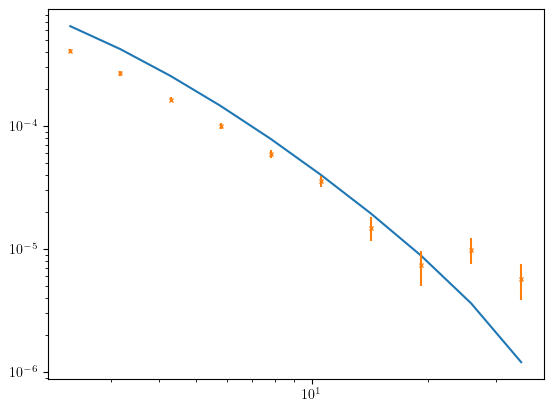

In [17]:
plt.figure()
plt.plot(r_hy, theory_profile_eval)
plt.errorbar(r_hy, xi_hy1, yerr=np.sqrt(np.diag(cov_hy1)), ls='', marker='x', ms=3.0, label='hy1')
plt.xscale('log')
plt.yscale('log')



In [88]:
theory_profile_eval/xi_hy1




array([1.24345855, 1.1603496 , 1.11321936, 1.02706512, 0.88627552,
       0.71632785, 0.88246536, 0.96101352, 0.17618378,        nan])

In [ ]:
# hp.nside2resol(nside, arcmin=True)


1.717743205908703